17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 76s 233ms/step - accuracy: 0.7929 - loss: 0.4355 - val_accuracy: 0.8680 - val_loss: 0.3137
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 71s 227ms/step - accuracy: 0.8964 - loss: 0.2631 - val_accuracy: 0.8662 - val_loss: 0.3127
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 73s 231ms/step - accuracy: 0.9347 - loss: 0.1768 - val_accuracy: 0.8664 - val_loss: 0.3389
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 31ms/step - accuracy: 0.8630 - loss: 0.3561
Test Accuracy: 0.8629599809646606


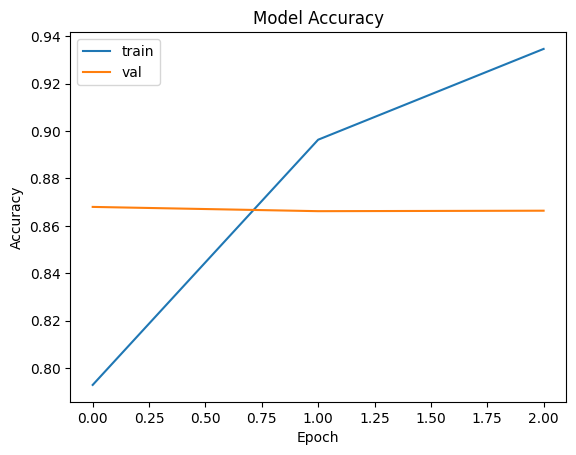

In [1]:
# ================= STEP 1: IMPORT =================
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ================= STEP 2: LOAD DATA =================
vocab_size = 10000

(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=vocab_size)

# ================= STEP 3: PADDING =================
max_length = 200

x_train = pad_sequences(x_train, maxlen=max_length)
x_test = pad_sequences(x_test, maxlen=max_length)

# ================= STEP 4: BUILD MODEL =================
model = keras.Sequential([
    layers.Embedding(vocab_size, 128, input_length=max_length),
    layers.LSTM(64),
    layers.Dense(1, activation='sigmoid')
])

# ================= STEP 5: COMPILE =================
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ================= STEP 6: TRAIN =================
history = model.fit(
    x_train, y_train,
    epochs=3,
    batch_size=64,
    validation_split=0.2
)

# ================= STEP 7: EVALUATE =================
loss, acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", acc)

# ================= STEP 8: PLOT =================
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()